In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

# Load master dataframe
master = pd.read_csv('data/processed/master.csv')

print(f'Loaded {len(master):,} counties')
print(f'Columns: {master.columns.tolist()}')

Loaded 2,947 counties
Columns: ['county', 'state', 'fips', 'population', 'depression_rate', 'mental_distress_rate', 'income', 'age', 'poverty', 'broadband', 'state_code', 'county_code', 'sci', 'poverty_rate', 'broadband_rate', 'income_quartile', 'region', 'economic_stress', 'digital_isolation', 'sci_effectiveness', 'region_encoded', 'cluster', 'cluster_name']


In [28]:
# Feature 1: Economic Stress Score
# Counties with low income AND high poverty are doubly stressed
master['economic_stress'] = (
    (1 - (master['income'] / master['income'].max())) * 0.6 +
    (master['poverty_rate'] / master['poverty_rate'].max()) * 0.4
)

# Feature 2: Digital Isolation Score
# High age + low broadband = digitally isolated county
master['digital_isolation'] = (
    (master['age'] / master['age'].max()) * 0.5 +
    (1 - (master['broadband_rate'] / master['broadband_rate'].max())) * 0.5
)

# Feature 3: SCI Effectiveness Score
# Does SCI actually help this county given its income level?
# Low income + high SCI = potentially harmful substitution effect
master['sci_effectiveness'] = master['sci'] * (master['income'] / master['income'].max())

print('New features created:')
print(master[['county', 'state', 'economic_stress', 
              'digital_isolation', 'sci_effectiveness']].head(5))

New features created:
      county           state  economic_stress  digital_isolation  \
0  Abbeville  South Carolina         0.537198           0.564337   
1     Acadia       Louisiana         0.595167           0.494296   
2   Accomack        Virginia         0.519570           0.541395   
3        Ada           Idaho         0.368438           0.478833   
4      Adair            Iowa         0.454491           0.514083   

   sci_effectiveness  
0           0.106158  
1           0.117575  
2           0.132314  
3           0.244339  
4           0.160136  


In [29]:
# Encode region as a number (ML models need numbers not text)
le = LabelEncoder()
master['region_encoded'] = le.fit_transform(master['region'].fillna('Other'))

# Define our feature columns (X) and target column (y)
feature_cols = [
    'sci',
    'income',
    'age', 
    'poverty_rate',
    'broadband_rate',
    'economic_stress',
    'digital_isolation',
    'sci_effectiveness',
    'region_encoded'
]

X = master[feature_cols]
y = master['depression_rate']

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape[0]:,} counties')
print(f'Testing set:   {X_test.shape[0]:,} counties')
print(f'Features used: {len(feature_cols)}')

Training set:  2,357 counties
Testing set:   590 counties
Features used: 9


In [30]:
# Define the model
model = xgb.XGBRegressor(
    n_estimators=300,      # number of trees to build
    max_depth=5,           # how deep each tree can go
    learning_rate=0.05,    # how much each tree corrects the previous
    subsample=0.8,         # use 80% of data per tree (prevents overfitting)
    colsample_bytree=0.8,  # use 80% of features per tree
    random_state=42
)

print('Training XGBoost model...')
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'\nModel Performance:')
print(f'  MAE (Mean Absolute Error): {mae:.2f}%')
print(f'  R² Score:                  {r2:.3f}')
print(f'\nInterpretation:')
print(f'  Our model predicts depression rate within ±{mae:.1f}% on average')
print(f'  R² of {r2:.2f} means model explains {r2*100:.0f}% of variance in depression rates')

Training XGBoost model...

Model Performance:
  MAE (Mean Absolute Error): 2.52%
  R² Score:                  0.179

Interpretation:
  Our model predicts depression rate within ±2.5% on average
  R² of 0.18 means model explains 18% of variance in depression rates


Calculating feature importance...


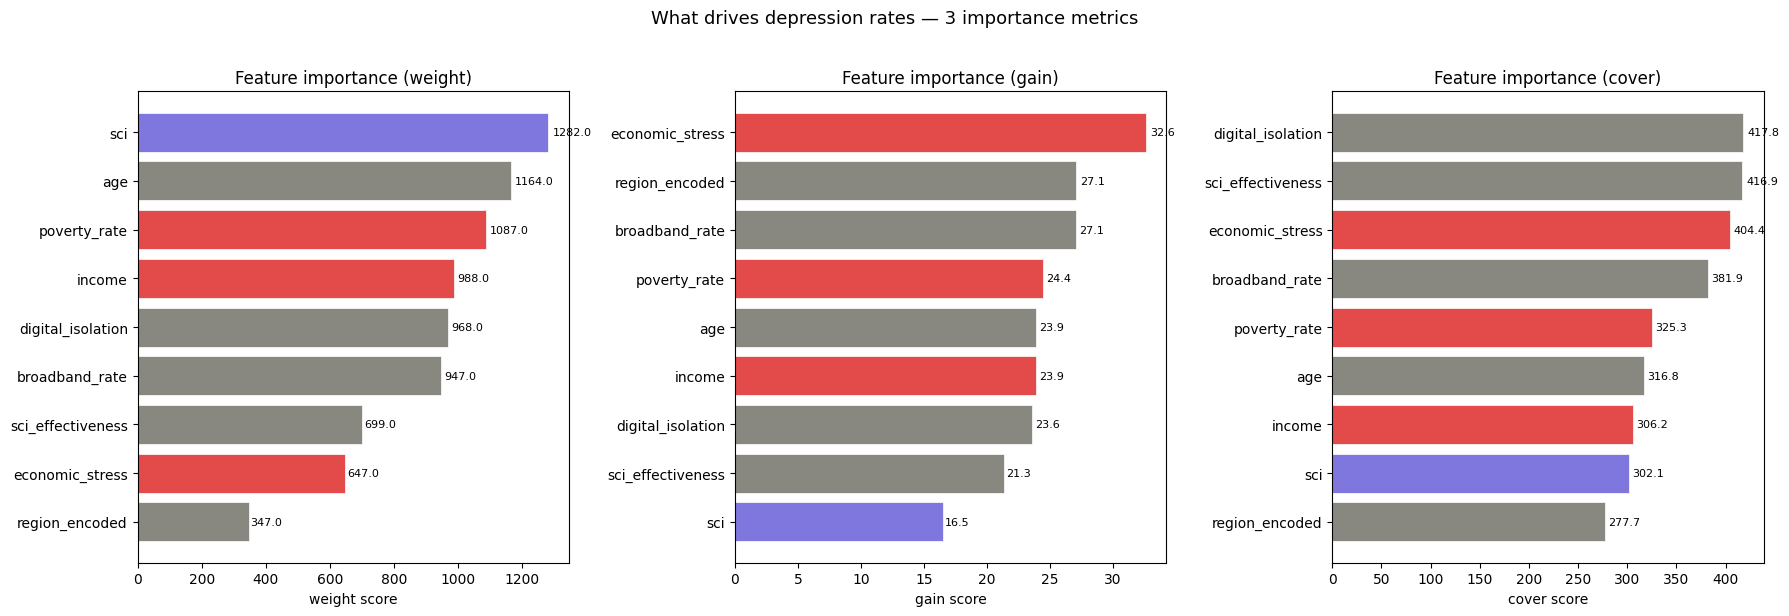

Chart saved!

Final feature ranking by GAIN:
  economic_stress               32.6  
  region_encoded                27.1  
  broadband_rate                27.1  
  poverty_rate                  24.4  
  age                           23.9  
  income                        23.9  
  digital_isolation             23.6  
  sci_effectiveness             21.3  
  sci                           16.5  


In [31]:
print('Calculating feature importance...')

# XGBoost 3.x uses real feature names directly — no mapping needed
importance_types = ['weight', 'gain', 'cover']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_type in zip(axes, importance_types):
    importance = model.get_booster().get_score(importance_type=imp_type)
    
    # XGBoost 3.x already returns real feature names
    imp_df = pd.DataFrame({
        'feature': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=True)
    
    colors = ['#E24B4A' if f in ['economic_stress', 'income', 'poverty_rate']
              else '#7F77DD' if f == 'sci'
              else '#888780'
              for f in imp_df['feature']]
    
    ax.barh(imp_df['feature'], imp_df['importance'],
            color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Feature importance ({imp_type})', fontsize=12)
    ax.set_xlabel(f'{imp_type} score')
    
    for i, (feat, imp) in enumerate(zip(imp_df['feature'],
                                         imp_df['importance'])):
        ax.text(imp * 1.01, i, f'{imp:.1f}', va='center', fontsize=8)

plt.suptitle('What drives depression rates — 3 importance metrics',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/processed/chart6_importance.png', dpi=120,
            bbox_inches='tight')
plt.show()
print('Chart saved!')

# Print final ranking
print('\nFinal feature ranking by GAIN:')
gain_scores = model.get_booster().get_score(importance_type='gain')
for feat, score in sorted(gain_scores.items(),
                          key=lambda x: x[1], reverse=True):
    bar = '█' * int(score / 100)
    print(f'  {feat:<25} {score:>8.1f}  {bar}')

In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale features (K-means needs scaled data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
master['cluster'] = kmeans.fit_predict(X_scaled)

# Describe each cluster
cluster_summary = master.groupby('cluster').agg(
    counties        = ('county', 'count'),
    avg_depression  = ('depression_rate', 'mean'),
    avg_income      = ('income', 'mean'),
    avg_sci         = ('sci', 'mean'),
    avg_poverty     = ('poverty_rate', 'mean')
).round(2)

print('Cluster profiles:')
print(cluster_summary)

Cluster profiles:
         counties  avg_depression  avg_income  avg_sci  avg_poverty
cluster                                                            
0            1055           23.51    58477.54     0.44        11.25
1             790           24.05    44844.71     0.35        19.54
2             439           22.00    85461.40     0.49         7.70
3             663           23.77    56722.57     0.48        14.88


Cluster names assigned:
                     counties  avg_depression  avg_income
cluster_name                                             
Middle America           1055           23.51    58477.54
Rural Vulnerable          663           23.77    56722.57
Struggling Isolated       790           24.05    44844.71
Thriving Connected        439           22.00    85461.40


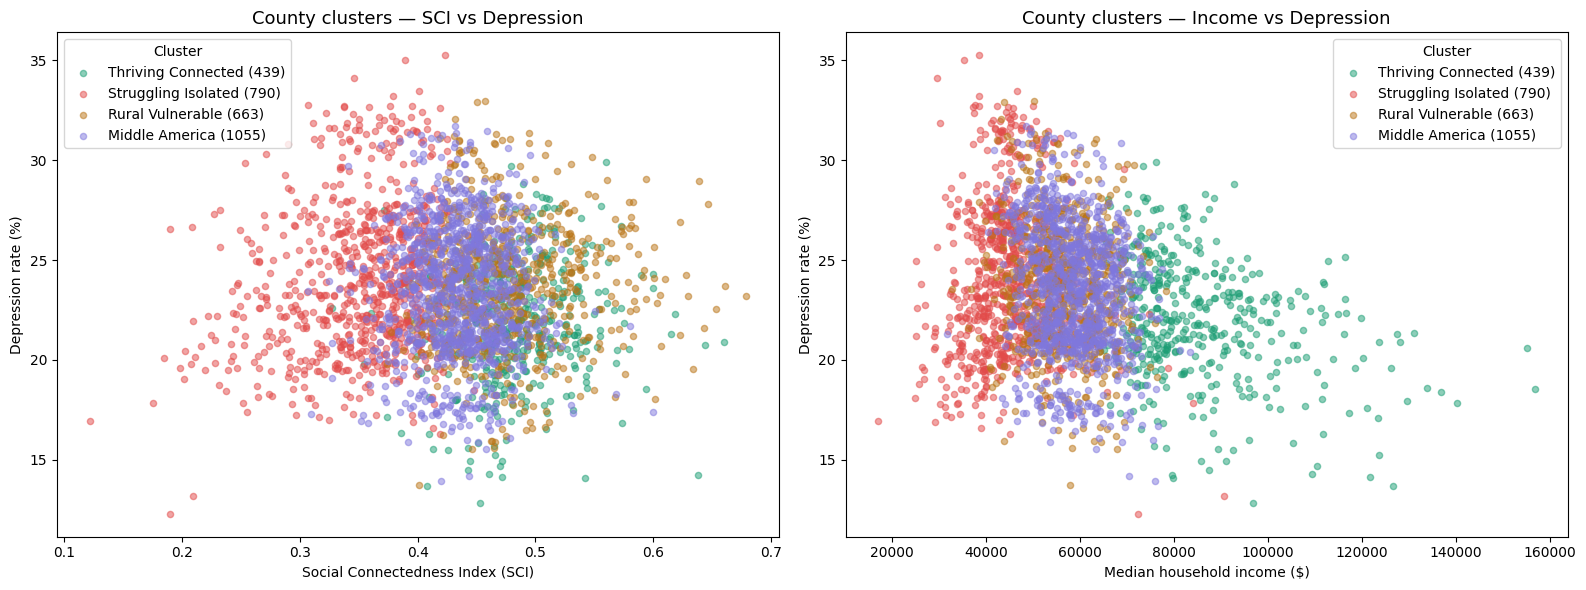

Cluster chart saved!


In [33]:
# Direct mapping based on your actual cluster numbers
cluster_names = {
    0: 'Middle America',
    1: 'Struggling Isolated',
    2: 'Thriving Connected',
    3: 'Rural Vulnerable'
}

master['cluster_name'] = master['cluster'].map(cluster_names)

print('Cluster names assigned:')
print(master.groupby('cluster_name').agg(
    counties       = ('county', 'count'),
    avg_depression = ('depression_rate', 'mean'),
    avg_income     = ('income', 'mean')
).round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_colors = {
    'Thriving Connected':  '#1D9E75',
    'Struggling Isolated': '#E24B4A',
    'Rural Vulnerable':    '#BA7517',
    'Middle America':      '#7F77DD'
}

# Left chart — SCI vs Depression
for name, color in cluster_colors.items():
    subset = master[master['cluster_name'] == name]
    if len(subset) > 0:
        axes[0].scatter(subset['sci'], subset['depression_rate'],
                       alpha=0.5, s=20, color=color,
                       label=f'{name} ({len(subset)})')

axes[0].set_title('County clusters — SCI vs Depression', fontsize=13)
axes[0].set_xlabel('Social Connectedness Index (SCI)')
axes[0].set_ylabel('Depression rate (%)')
axes[0].legend(title='Cluster', loc='upper left')

# Right chart — Income vs Depression
for name, color in cluster_colors.items():
    subset = master[master['cluster_name'] == name]
    if len(subset) > 0:
        axes[1].scatter(subset['income'], subset['depression_rate'],
                       alpha=0.5, s=20, color=color,
                       label=f'{name} ({len(subset)})')

axes[1].set_title('County clusters — Income vs Depression', fontsize=13)
axes[1].set_xlabel('Median household income ($)')
axes[1].set_ylabel('Depression rate (%)')
axes[1].legend(title='Cluster', loc='upper right')

plt.tight_layout()
plt.savefig('data/processed/chart9_clusters.png', dpi=120)
plt.show()
print('Cluster chart saved!')
# ```

# ---

# ### Most interesting finding from your clusters

# **Rural Vulnerable (Cluster 3)** is the paradox cluster in pure form:
# ```
# SCI = 0.48  ← above average connectivity
# Depression = 23.77%  ← still high despite connectivity
# Income = $56,722  ← middle income, not the poorest

In [36]:
import os
import pickle

with open('data/processed/xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

master.to_csv('data/processed/master.csv', index=False)

print('Saved!')
print('master.csv exists:', os.path.exists('data/processed/master.csv'))
print('xgb_model.pkl exists:', os.path.exists('data/processed/xgb_model.pkl'))


Saved!
master.csv exists: True
xgb_model.pkl exists: True


FileNotFoundError: [Errno 2] No such file or directory: 'dashboard/app.py'